One file to contain all haar sampler inner product definition for testing

In [59]:
import numpy as np
from types import SimpleNamespace
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator
from pauliarray import PauliArray
from qiskit_aer import AerSimulator
from qiskit import transpile
from pauliarray.diagonalisation.commutating_paulis.with_qiskit_circuits import general_to_diagonal
from pauliarray.partition.commutating_paulis.exclusive_fct import partition_bitwise_commutating

In [60]:
test = False

In [61]:
class PauliSamplerResultItem:
    """
    Single expectation-value result.

    This object is intentionally made compatible with both:

        np.real(result[0])
    """

    def __init__(self, evs):
        self.data = SimpleNamespace(evs=evs)

    def __complex__(self):
        return complex(self.data.evs)

    def __float__(self):
        return float(np.real(self.data.evs))

    def __array__(self, dtype=None):
        return np.asarray(self.data.evs, dtype=dtype)

    def __repr__(self):
        return repr(self.data.evs)


In [62]:

class PauliSamplerJob:
    """
    Small job-like wrapper so that we can call:

        job = estimator.run(...)
        result = job.result()
    """

    def __init__(self, result_items):
        self._result_items = result_items

    def result(self):
        return self._result_items

In [63]:

class CommutingPauliSampler:
    """
    Estimate <psi|O|psi> for a SparsePauliOp observable O.

    Internally, this class:

        1. extracts Pauli strings from O
        2. builds a PauliArray
        3. groups terms into bitwise commuting cliques
        4. diagonalizes each clique using pauliarray diagonalization
        5. applies the diagonalizing Clifford circuit
        6. samples bitstrings
        7. reconstructs every <P_j>
        8. returns sum_j c_j <P_j>

    Interface:

        estimator = CommutingPauliSampler(shots=4000)

        value = estimator.run(state, observable).result()[0]

    Also supports:

        value = estimator.run([(state, observable)]).result()[0].data.evs
    """

    def __init__(
        self,
        shots=5,
        backend=None,
        epsilon=1e-12,
    ):
        self.shots = shots
        self.eps = epsilon
        self._diagonalization_cache = {}

        if backend is not None:
            self.backend = backend
        else:
            self.backend = AerSimulator()

    # ------------------------------------------------------------------
    # Public estimator-like interface
    # ------------------------------------------------------------------

    def run(self, state, observable=None):
        """
        Supports both:

            run(state, observable)

        and:

            run([(state, observable)])

        Returns a PauliSamplerJob object whose .result() gives a list.
        """

        # Case 1:
        #     run([(state, observable)])
        if observable is None and isinstance(state, list):
            jobs = state
            result_items = []

            for item in jobs:
                if len(item) != 2:
                    raise ValueError(
                        "Each item must be a pair: (state_circuit, observable)"
                    )

                state_circuit, obs = item
                ev = self._estimate_one_observable(state_circuit, obs)
                result_items.append(PauliSamplerResultItem(ev))

            return PauliSamplerJob(result_items)

        # Case 2:
        #     run(state, observable)
        if observable is None:
            raise ValueError("You must provide an observable.")

        ev = self._estimate_one_observable(state, observable)

        return PauliSamplerJob([
            PauliSamplerResultItem(ev)
        ])

    # ------------------------------------------------------------------
    # Main estimator
    # ------------------------------------------------------------------

    def _estimate_one_observable(self, state_circuit, observable):
        """
        Estimate <state|observable|state>.
        """

        if not isinstance(observable, SparsePauliOp):
            raise TypeError("observable must be a qiskit.quantum_info.SparsePauliOp")

        labels = list(observable.paulis.to_labels())
        coeffs = np.asarray(observable.coeffs, dtype=complex)

        labels, coeffs = self._truncate_terms(labels, coeffs)

        if len(labels) == 0:
            return 0.0 + 0.0j, {
                "message": "Observable was empty after truncation."
            }

        all_expvals = {}

        diag_data = self._get_diagonalization_data(labels)
        general_cliques = diag_data["cliques"]

        for clique_info in diag_data["clique_data"]:
            clique = clique_info["clique"]
            clique_labels = clique_info["clique_labels"]
            transformed_clique = clique_info["transformed_clique"]
            phases = clique_info["phases"]
            qc_diag = clique_info["qc_diag"]

            meas_circuit = self._build_measurement_circuit(state_circuit, qc_diag)

            counts = self._run_counts(meas_circuit)

            expvals = self._reconstruct_clique_expectations(
                counts,
                clique,
                labels,
                transformed_clique,
                phases,
            )

            all_expvals.update(expvals)

        value = 0.0 + 0.0j

        for i, coeff in enumerate(coeffs):
            value += coeff * all_expvals[i]

        # For Hermitian observables, imaginary part should be numerical noise.
        if abs(value.imag) < 100 * self.eps:
            value = value.real + 0.0j


        return value

    # ------------------------------------------------------------------
    # Term truncation
    # ------------------------------------------------------------------

    def _truncate_terms(self, labels, coeffs):
        """
        Drop terms with tiny coefficients.
        """

        keep = np.abs(coeffs) >= self.eps

        new_labels = [label for label, k in zip(labels, keep) if k]
        new_coeffs = coeffs[keep]

        return new_labels, new_coeffs

    # ------------------------------------------------------------------
    # Measurement circuit
    # ------------------------------------------------------------------

    def _get_diagonalization_data(self, labels):
        key = tuple(labels)

        if key in self._diagonalization_cache:
            if test:
                print("Diagonalization cache hit for key:", key)
            return self._diagonalization_cache[key]

        if test:
            print("diagonalizing cliques for labels:", labels)

        paulis = PauliArray.from_labels(labels)
        general_cliques = partition_bitwise_commutating(paulis)

        clique_data = []

        for clique_id, clique in enumerate(general_cliques):
            clique_labels = [labels[i] for i in clique]
            clique_paulis = PauliArray.from_labels(clique_labels)

            (diag_paulis, factors), circuit = general_to_diagonal(
                clique_paulis,
                force_single_qubit_generators=False,
            )

            transformed_clique = diag_paulis
            phases = factors
            qc_diag = circuit

            

            clique_data.append({
                "clique_id": clique_id,
                "clique": clique,
                "clique_labels": clique_labels,
                "transformed_clique": transformed_clique,
                "transformed_labels": self._pauliarray_to_labels(transformed_clique),
                "phases": phases,
                "qc_diag": qc_diag,
            })

        data = {
            "labels": labels,
            "cliques": general_cliques,
            "clique_data": clique_data,
        }

        self._diagonalization_cache[key] = data
        return data

    def _build_measurement_circuit(self, state_circuit, qc_diag):
        """
        Build:

            state preparation
            diagonalizing Clifford
            computational-basis measurement
        """

        meas_circuit = state_circuit.copy()

        meas_circuit.compose(qc_diag, inplace=True)

        meas_circuit.measure_all()

        return meas_circuit



    def _run_counts(self, circuit):
        
        job = self.backend.run(circuit, shots=self.shots)
        result = job.result()
        counts = result.get_counts()

        return counts
    # ------------------------------------------------------------------
    # Reconstruction from counts
    # ------------------------------------------------------------------

    def _bit_to_eigenvalue(self, bit):
        """
        Computational basis bit to Z eigenvalue.

            bit 0 -> +1
            bit 1 -> -1
        """

        return +1 if bit == "0" else -1

    def _expval_diagonal_pauli_from_counts(self, counts, diagonal_label):
            total = 0.0
            shots = 0

            for bitstring, count in counts.items():
                bitstring = bitstring.replace(" ", "")
                bits_by_qubit = bitstring[::-1]

                value = 1

                for q, p in enumerate(diagonal_label):
                    if p == "Z":
                        value *= self._bit_to_eigenvalue(bits_by_qubit[q])
                    elif p == "I":
                        pass
                    else:
                        raise ValueError(f"Expected I/Z only, got {diagonal_label}")

                total += count * value
                shots += count

            return total / shots

    def _reconstruct_clique_expectations(
        self,
        counts,
        clique,
        labels,
        transformed_clique,
        phases,
    ):
        """
        Reconstruct <P_j> for every original Pauli string in one clique.
        """

        transformed_labels = self._pauliarray_to_labels(transformed_clique)

        expvals = {}

        for local_idx, global_idx in enumerate(clique):
            original_label = labels[global_idx]
            diagonal_label = transformed_labels[local_idx]
            phase = phases[local_idx]

            diag_expval = self._expval_diagonal_pauli_from_counts(
                counts,
                diagonal_label,
            )

            original_expval = phase * diag_expval

            # Tiny imaginary numerical noise cleanup
            if abs(np.imag(original_expval)) < 100 * self.eps:
                original_expval = np.real(original_expval)

            expvals[global_idx] = original_expval



        return expvals
    
    # ------------------------------------------------------------------
    # PauliArray helper
    # ------------------------------------------------------------------

    def _pauliarray_to_labels(self, arr):
        """
        Convert PauliArray back to a list of labels.
        """

        if hasattr(arr, "to_labels"):
            return list(arr.to_labels())

        # Fallback using x_strings/z_strings.
        # This assumes the PauliArray qubit order matches label order.
        labels = []

        for row in range(arr.size):
            chars = []

            for q in range(arr.num_qubits):
                x = bool(arr.x_strings[row, q])
                z = bool(arr.z_strings[row, q])

                if not x and not z:
                    chars.append("I")
                elif x and not z:
                    chars.append("X")
                elif not x and z:
                    chars.append("Z")
                else:
                    chars.append("Y")

            labels.append("".join(chars))

        return labels    

In [64]:
from LiouvilleLanczos.Lanczos_components import Inner_product as Base_inner_product 
from LiouvilleLanczos.Lanczos_components import Summation as Base_summation
from LiouvilleLanczos.Lanczos_components import Liouvillian as BaseLiouvillian
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import StatePreparation

from typing import Optional

In [65]:
def relative_simplify_spo(ope:SparsePauliOp,eps:float):
    """
    relative simplify truncates terms with a relative participation smaller than eps.
    Qiskit quantum info sparse pauli operator based implementation.
    performs much better than slo.
    """

    return ope.simplify(atol=eps,rtol=eps)

def separate_imag(op: SparsePauliOp):
    """
    split a non hermiation operator in two hermitian operator.
    op = A+iB
    input: op
    returns: A,B
    """
    coeffs_real = []
    coeffs_img = []
    for coeff in op.coeffs:
        coeffs_real.append(np.real(coeff))
        coeffs_img.append(np.imag(coeff))
    pauli_op_real = SparsePauliOp(op.paulis, coeffs_real).chop()
    pauli_op_imag = SparsePauliOp(op.paulis, coeffs_img).chop()
    return pauli_op_real, pauli_op_imag

In [66]:
import time
class inner_product_haar_sampler(Base_inner_product):

    """
    Operator Inner product implementation for sparse pauli operators.
    Compute $\\bra{\\psi} \\rho \\{A,B^\\dagger \\} \\ket{\\psi}$
    where $\\ket{\\psi}$ is a quantum state specified by a quantum circuit.
    $A$ and $B$ are quantum operators specified by sparse pauli operators.
    Uses a custom sampler to achieve haar random SU(2) symmetry sampling.
    """
    def __init__(self, state: QuantumCircuit, estimator, epsilon = 1e-3):

        ### base circuit U(theta,phi,gamma)|g> and Haar sampler (theta phi gamma) 
        ### every time i __call__ the inner product it needs to run the parametrized circuit 
        ### 5 shot per haar sample 
        ### 1000 haar samples should be enough
        ### pauli qubit wise commuting function should be better
        ### transpile once per ground state qc.
        
        """
        Constructor for the inner product.
        requires
        - state: a quantum circuit that produces a desired state. (not haar sampled yet just VQE state)
        - sampler: a custom sampler to estimate the expectation value given a state |psi>. --- IGNORE ---
        - epsilon: target accuracy, smaller relative values are truncated. 
        """
        self.state = state 
        self.estimator = estimator
        self.eps = epsilon
        self.counter = 0
        self._last_counter_time = time.perf_counter()
        self.times = []
        self.haar_state_template, self.alpha , self.beta, self.gamma = self.make_parametrized_haar_state()
        
    def __call__(self,A:SparsePauliOp,B:SparsePauliOp,real_result:bool=False,Name:Optional[str]=None):
        """
        compute the innerproduct between that A and B operator.
        set real_result to True to bypass computation of an imaginary part in the result.
        Set a Name to easily identify the associated jobs on IBM quantum.
        """
        
        Bc = B.adjoint()
        f = A@Bc+Bc@A
        f = relative_simplify_spo(f,self.eps)
        obs_real, obs_imag = separate_imag(f)        
        out = complex(0)
        num_haar_sample = 1001 


        now = time.perf_counter()
        dt = now - self._last_counter_time
        self.times.append(dt)
        if self.counter % 5 == 0 or self.times[-1] > 60:
            print("-------"*10)
            print(f"counter:", self.counter)
            print(f"time since last counter: {dt:.2f} seconds")
            print("-------"*10)
        
        if test:
            print("observable:", obs_real)

        self.counter = self.counter + 1
        self._last_counter_time = now

        for t in range(num_haar_sample):
            if test:
                print("-----------haar sample number ", t + 1, "out of", num_haar_sample, "-------------")
            bind = {}
            a, b, g = self.sample_haar_su2()
            for q in range(self.haar_state_template.num_qubits):
                bind[self.alpha[q]] = a
                bind[self.beta[q]]  = b
                bind[self.gamma[q]] = g

            state = self.haar_state_template.assign_parameters(bind, inplace=False)

            if any(np.abs(obs_real.coeffs) >= self.eps):
                result = self.estimator.run(state, obs_real).result()[0]
                out += np.real(result)

            if not real_result and any(np.abs(obs_imag.coeffs) >= self.eps):
                result = self.estimator.run(state, obs_imag).result()[0]
                out += 1j * np.real(result)

        return out / num_haar_sample
    
    @staticmethod
    def sample_haar_su2():
        alpha = np.random.uniform(0, 2 * np.pi)
        u     = np.random.uniform(0, 1)
        beta  = 2 * np.arccos(np.sqrt(u))   # absorbs sin(β) Jacobian
        gamma = np.random.uniform(0, 2 * np.pi)
        return alpha, beta, gamma
    
    
    def make_parametrized_haar_state(self):
        
        state = self.state.copy()
        state.barrier()
        n = state.num_qubits

        alpha = ParameterVector("alpha", n)
        beta  = ParameterVector("beta", n)
        gamma = ParameterVector("gamma", n)

        haar_layer = QuantumCircuit(n)

        for q in range(n):
            # Native-style version of RZ(gamma) RY(beta) RZ(alpha)
            haar_layer.rz(gamma[q] + np.pi, q)
            haar_layer.sx(q)
            haar_layer.rz(beta[q] + np.pi, q)
            haar_layer.sx(q)
            haar_layer.rz(alpha[q], q)
        

        state.compose(haar_layer, inplace=True)

        return state, alpha, beta, gamma


In [67]:
from LiouvilleLanczos.Quantum_computer.Hamiltonian import Line_Hubbard, BoundaryCondition
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()

def fermionic_op_to_matrix(op):
    qubit_op = mapper.map(op)
    return np.asarray(qubit_op.to_matrix(), dtype=complex)

In [68]:
def statevector_to_circuit(psi, name="GS"):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)

    num_qubits = int(np.log2(len(psi)))

    if 2**num_qubits != len(psi):
        raise ValueError("Statevector length must be a power of 2.")

    qc = QuantumCircuit(num_qubits, name=name)

    prep = StatePreparation(psi)
    qc.append(prep, range(num_qubits))
    
    qc = transpile(qc, AerSimulator(), optimization_level=0)

    return qc

def to_sparse_pauli(op):
    """
    Convert FermionicOp -> SparsePauliOp.
    Leave SparsePauliOp unchanged.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if isinstance(op, FermionicOp):
        return mapper.map(op).simplify(atol=1e-12)

    raise TypeError(f"Unsupported operator type: {type(op)}")

def relative_simplify_spo(ope:SparsePauliOp,eps:float):
    """
    relative simplify truncates terms with a relative participation smaller than eps.
    Qiskit quantum info sparse pauli operator based implementation.
    performs much better than slo.
    """

    return ope.simplify(atol=eps)

In [69]:
class Liouvillian_spo(BaseLiouvillian):
    """
    Sparse pauli operator based implementation of the Liouvillian.
    """
    def __init__(self,eps = 1e-10):
        """
        initialise with a relative precision. operator with smaller coefficients 
        are truncated.
        """
        self.eps = eps
    def __call__(self,H,A):
        """
        Compute the result of the Liouvillian for system with Hamiltonian H on 
        operator A.
        """
        comm = H@A-A@H
        return relative_simplify_spo(comm,self.eps)

class sum_spo(Base_summation):
    """
    Sum up to 3 sparse pauli operator
    """
    def __init__(self,eps=1e-10):
        """
        target relative precision of the results.
        """
        self.eps = eps
    def __call__(self,*X):
        """
        perform the sum
        """
        if len(X) > 2:
            A =  X[0]+X[1]+X[2]
        else:
            A = X[0]+X[1]
        return relative_simplify_spo(A,self.eps)

In [70]:
def ground_state_from_vector(psi):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)

    n_qubits = int(np.log2(len(psi)))

    qc = QuantumCircuit(n_qubits)
    qc.initialize(psi, range(n_qubits))
    return qc


def candidate_ground_state_circuits(seed=123, reps=2):

    """
    Return a list of candidate ground-state circuits.

    You can pass each circuit into your estimator / Lanczos / Green's function
    pipeline as the trial ground state.

    Parameters
    ----------
    num_qubits : int
        Number of qubits in your Hilbert space.
    seed : int
        Random seed for random ansatz circuits.
    reps : int
        Number of layers for the random shallow ansatz.

    Returns
    -------
    circuits : list[QuantumCircuit]
    """
    num_qubits = 6
    rng = np.random.default_rng(seed)
    circuits = []

    # ------------------------------------------------------------
    # 1. |000...0>
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="zero_state")
    circuits.append(qc)

    # ------------------------------------------------------------
    # 2. |111...1>
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="all_ones")
    for q in range(num_qubits):
        qc.x(q)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 3. Néel state |1010...>
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="neel_1010")
    for q in range(num_qubits):
        if q % 2 == 0:
            qc.x(q)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 4. Néel state |0101...>
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="neel_0101")
    for q in range(num_qubits):
        if q % 2 == 1:
            qc.x(q)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 5. Uniform product superposition |+>^n
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="plus_state")
    for q in range(num_qubits):
        qc.h(q)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 6. Alternating X-basis product state |+-+-...>
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="alternating_pm")
    for q in range(num_qubits):
        qc.h(q)
        if q % 2 == 1:
            qc.z(q)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 7. Bell-pair product state
    #    Pairs: (0,1), (2,3), ...
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="bell_pairs")
    for q in range(0, num_qubits - 1, 2):
        qc.h(q)
        qc.cx(q, q + 1)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 8. Shifted Bell-pair product state
    #    Pairs: (1,2), (3,4), ...
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="shifted_bell_pairs")
    for q in range(1, num_qubits - 1, 2):
        qc.h(q)
        qc.cx(q, q + 1)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 9. GHZ state
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="ghz")
    qc.h(0)
    for q in range(1, num_qubits):
        qc.cx(0, q)
    circuits.append(qc)

    # ------------------------------------------------------------
    # 10. Random shallow hardware-efficient ansatz
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="random_shallow_ansatz")

    for _ in range(reps):
        for q in range(num_qubits):
            qc.ry(rng.uniform(0, 2 * np.pi), q)
            qc.rz(rng.uniform(0, 2 * np.pi), q)

        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)

    circuits.append(qc)

    # ------------------------------------------------------------
    # 11. Random shallow ansatz with ring entanglement
    # ------------------------------------------------------------
    qc = QuantumCircuit(num_qubits, name="random_ring_ansatz")

    for _ in range(reps):
        for q in range(num_qubits):
            qc.ry(rng.uniform(0, 2 * np.pi), q)
            qc.rz(rng.uniform(0, 2 * np.pi), q)

        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)

        if num_qubits > 2:
            qc.cx(num_qubits - 1, 0)

    circuits.append(qc)

    return circuits

ground_states = candidate_ground_state_circuits(seed=123, reps=2)

In [135]:
U = 4 
Ham = Line_Hubbard(
    -1,
    U/2,
    U,
    3,
    boundary_condition=BoundaryCondition.OPEN
)

Hmat = fermionic_op_to_matrix(Ham)
E, S = np.linalg.eigh(Hmat)

GS = S[:, 0]
GS = ground_state_from_vector(GS)

C0 = FermionicOp({"+_0": 1}, num_spin_orbitals=6)

GS = ground_states[7]

print(GS)


               
q_0: ──────────
     ┌───┐     
q_1: ┤ H ├──■──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
     ┌───┐└───┘
q_3: ┤ H ├──■──
     └───┘┌─┴─┐
q_4: ─────┤ X ├
          └───┘
q_5: ──────────
               


In [136]:
from LiouvilleLanczos.Lanczos import Lanczos

estimator = CommutingPauliSampler(shots=5)

lanczos = Lanczos(inner_product=inner_product_haar_sampler(state= GS  ,estimator=estimator), liouvillian=Liouvillian_spo(), sum=sum_spo())

lanczos_result = lanczos(
    H=to_sparse_pauli(Ham),
    f_0= to_sparse_pauli(C0),
    max_k=4
)


----------------------------------------------------------------------
counter: 0
time since last counter: 0.00 seconds
----------------------------------------------------------------------
----------------------------------------------------------------------
counter: 5
time since last counter: 1.45 seconds
----------------------------------------------------------------------


In [137]:
from qiskit.quantum_info import SparsePauliOp, Statevector

class exact_inner_product:
    def __init__(self, state, num_haar_sample=1001, epsilon=1e-12):
        self.state = state
        self.num_haar_sample = num_haar_sample
        self.eps = epsilon

        self.psi0 = Statevector.from_instruction(state).data
        self.psi0 = self.psi0 / np.linalg.norm(self.psi0)

        self.n = state.num_qubits

    def __call__(self, A: SparsePauliOp, B: SparsePauliOp, real_result=False, Name=None):
        Bc = B.adjoint()
        F = A @ Bc + Bc @ A
        F = F.simplify(atol=self.eps)

        Fmat = F.to_matrix(sparse=False)

        out = 0.0 + 0.0j

        for _ in range(self.num_haar_sample):
            U = self._global_tensor_haar_unitary()
            psi = U @ self.psi0
            out += np.vdot(psi, Fmat @ psi)

        val = out / self.num_haar_sample

        if real_result or abs(val.imag) < 100 * self.eps:
            return float(np.real(val))

        return val

    @staticmethod
    def sample_haar_su2():
        alpha = np.random.uniform(0, 2 * np.pi)
        u = np.random.uniform(0, 1)
        beta = 2 * np.arccos(np.sqrt(u))
        gamma = np.random.uniform(0, 2 * np.pi)
        return alpha, beta, gamma

    @staticmethod
    def su2_matrix(alpha, beta, gamma):
        Rz_a = np.array([
            [np.exp(-0.5j * alpha), 0],
            [0, np.exp(0.5j * alpha)],
        ])

        Ry_b = np.array([
            [np.cos(beta / 2), -np.sin(beta / 2)],
            [np.sin(beta / 2),  np.cos(beta / 2)],
        ])

        Rz_g = np.array([
            [np.exp(-0.5j * gamma), 0],
            [0, np.exp(0.5j * gamma)],
        ])

        return Rz_g @ Ry_b @ Rz_a

    def _global_tensor_haar_unitary(self):
        a, b, g = self.sample_haar_su2()
        U1 = self.su2_matrix(a, b, g)

        U = np.array([[1.0 + 0.0j]])

        for _ in range(self.n):
            U = np.kron(U1, U)

        return U

In [138]:
exact_ip = exact_inner_product(GS)

lanczos_exact = Lanczos(
    inner_product=exact_ip,
    liouvillian=Liouvillian_spo(),
    sum=sum_spo(),
)

a_exact, b_exact = lanczos_exact(
    H=to_sparse_pauli(Ham),
    f_0=to_sparse_pauli(C0),
    max_k=4,
)

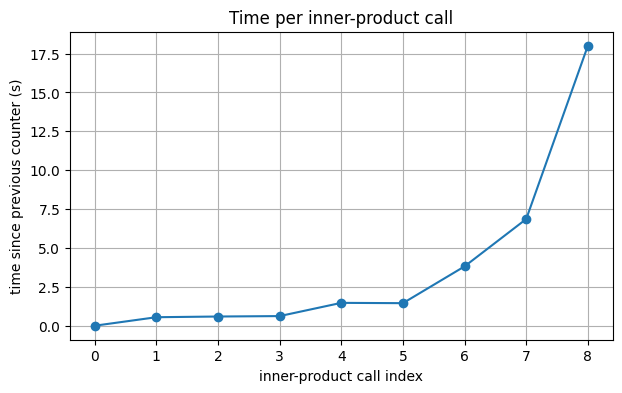

In [139]:
import matplotlib.pyplot as plt

times  = np.array(lanczos.inner_prod.times)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(times)), times, marker="o")
plt.xlabel("inner-product call index")
plt.ylabel("time since previous counter (s)")
plt.title("Time per inner-product call")
plt.grid(True)
plt.show()



In [140]:
"""
times = [3.33633303e-03 5.73127500e-01 6.36635000e-01 6.07101500e-01
 1.22527054e+00 1.25110683e+00 3.73562921e+00 5.63154925e+00
 2.08225436e+01 2.72922347e+01 5.48311592e+01 7.25675559e+01
 8.89380237e+01 8.81034013e+01 1.00105788e+02 1.09958592e+02
 1.07624487e+02 1.04659453e+02 1.05131554e+02 1.16522978e+02
 1.18209057e+02]
"""

'\ntimes = [3.33633303e-03 5.73127500e-01 6.36635000e-01 6.07101500e-01\n 1.22527054e+00 1.25110683e+00 3.73562921e+00 5.63154925e+00\n 2.08225436e+01 2.72922347e+01 5.48311592e+01 7.25675559e+01\n 8.89380237e+01 8.81034013e+01 1.00105788e+02 1.09958592e+02\n 1.07624487e+02 1.04659453e+02 1.05131554e+02 1.16522978e+02\n 1.18209057e+02]\n'

In [141]:
print("a exact:", a_exact)
print("b exact:", b_exact)

print("a sampled:", lanczos_result[0])
print("b sampled:", lanczos_result[1])

a exact: [7.257601685379616e-18, -3.799744107297725e-18, -0.07437315134528513, 0.0527478464010393]
b exact: [np.float64(1.0), np.float64(2.23606797749979), np.float64(1.8439088914585933), np.float64(2.315244236909699)]
a sampled: [np.complex128(-0.018781218781218776+0j), np.complex128(-0.029489923660677885+0j), np.complex128(0.04470861470486825+0j), np.complex128(0.060775314945358566+0j)]
b sampled: [np.complex128(1+0j), np.complex128(2.236170343228399+0j), np.complex128(1.8438160900819365+0j), np.complex128(2.304197212737292+0j)]


In [142]:
"""
a_exact = [0.01874937527460068, -0.012384533626324011, 0.12702479047841425, -0.24434656392870274, 0.19294594885231023, 0.27372274694108156, 0.041867298913176955, -1.0113349699996212, 0.33310270968404837, -0.6795794322417894]
b_exact = [np.float64(1.0), np.float64(2.235969128098751), np.float64(1.8438498745688316), np.float64(2.4675397965221335), np.float64(2.0097697271600135), np.float64(2.5509302082833596), np.float64(2.742169094581934), np.float64(3.837060286294599), np.float64(4.322603142829394), np.float64(4.412666590665861)]
a_sampled = [np.complex128(-0.04355644355644354+0j), np.complex128(-0.007768821039683929+0j), np.complex128(-0.06974595222003309+0j), np.complex128(0.2195340118858333+0j), np.complex128(-0.5355825401481599+0j), np.complex128(0.37174484558344595+0j), np.complex128(-0.5259583960086676+0j), np.complex128(0.8119404917058912+0j), np.complex128(-1.048844186663629+0j), np.complex128(-0.43120680574291287+0j)]
b_sampled = [np.complex128(1+0j), np.complex128(2.2357994192491253+0j), np.complex128(1.84258386467893+0j), np.complex128(2.3138327254372952+0j), np.complex128(1.9503129369764385+0j), np.complex128(2.5259607788686385+0j), np.complex128(2.8813344646534396+0j), np.complex128(3.523847222124632+0j), np.complex128(4.146929421089937+0j), np.complex128(4.117345848337153+0j)]
"""


'\na_exact = [0.01874937527460068, -0.012384533626324011, 0.12702479047841425, -0.24434656392870274, 0.19294594885231023, 0.27372274694108156, 0.041867298913176955, -1.0113349699996212, 0.33310270968404837, -0.6795794322417894]\nb_exact = [np.float64(1.0), np.float64(2.235969128098751), np.float64(1.8438498745688316), np.float64(2.4675397965221335), np.float64(2.0097697271600135), np.float64(2.5509302082833596), np.float64(2.742169094581934), np.float64(3.837060286294599), np.float64(4.322603142829394), np.float64(4.412666590665861)]\na_sampled = [np.complex128(-0.04355644355644354+0j), np.complex128(-0.007768821039683929+0j), np.complex128(-0.06974595222003309+0j), np.complex128(0.2195340118858333+0j), np.complex128(-0.5355825401481599+0j), np.complex128(0.37174484558344595+0j), np.complex128(-0.5259583960086676+0j), np.complex128(0.8119404917058912+0j), np.complex128(-1.048844186663629+0j), np.complex128(-0.43120680574291287+0j)]\nb_sampled = [np.complex128(1+0j), np.complex128(2.235

In [143]:
from LiouvilleLanczos.Green import CF_Green as CF

exact_green = CF(a_exact, b_exact)
sample_green = CF(lanczos_result[0], lanczos_result[1])
#sample_green = CF(a_sampled, b_sampled)



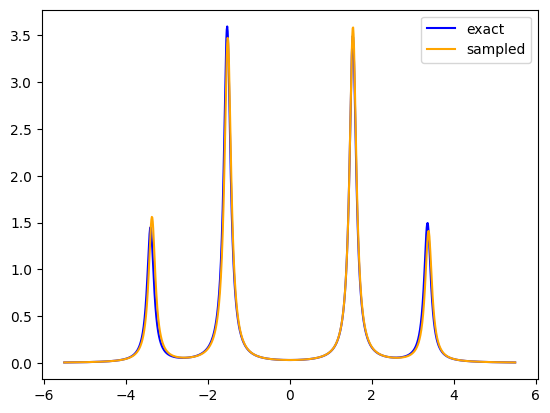

In [144]:

w = np.linspace(-5.5,5.5,1000)-1e-1j
plt.plot(w,np.imag(exact_green(w)), label="exact", color="blue")
plt.plot(w,np.imag(sample_green(w)), label="sampled", color="orange")
plt.legend()
plt.show()
